# Imports and System Check

In [1]:
import os
import time
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torch.optim.lr_scheduler import CosineAnnealingLR

# Check for GPU acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Device Name: NVIDIA GeForce RTX 4060 Laptop GPU


# Model Architecture Definition

In [2]:
class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.fc(x).view(b, c, 1, 1)
        return x * w

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SqueezeExcitation(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class EnhancedEmotionNet96(nn.Module):
    def __init__(self, num_classes=8):  # Updated default parameter to 8
        super().__init__()
        
        self.prep = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.layer1 = ResidualBlock(64, 64, stride=1)   # (64, 96, 96)
        self.pool1 = nn.MaxPool2d(2)                    # (64, 48, 48)
        
        self.layer2 = ResidualBlock(64, 128, stride=1)  # (128, 48, 48)
        self.pool2 = nn.MaxPool2d(2)                    # (128, 24, 24)
        
        self.layer3 = ResidualBlock(128, 256, stride=1) # (256, 24, 24)
        self.pool3 = nn.MaxPool2d(2)                    # (256, 12, 12)
        
        self.layer4 = ResidualBlock(256, 512, stride=1) # (512, 12, 12)
        self.pool4 = nn.MaxPool2d(2)                    # (512, 6, 6)

        # Fixes structural alignment issue completely across dimension branches
        self.mid_bridge = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(6) # Rigidly enforces 6x6 target shape
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(23040, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.prep(x)
        x1 = self.pool1(self.layer1(x))
        x2 = self.pool2(self.layer2(x1))
        x3 = self.pool3(self.layer3(x2))  
        x4 = self.pool4(self.layer4(x3))  
        
        mid_features = self.mid_bridge(x3)
        fused = torch.cat([x4, mid_features], dim=1)
        return self.classifier(fused)

# Data Loaders and Augmentation Pipeline

In [3]:
# ==========================================
# CONFIGURATION - ADJUST PATH HERE
# ==========================================
SPLIT_DIR = "data/affectnet_splits/Split_90_10" 
BATCH_SIZE = 64
NUM_CLASSES = 8

# Augmentations designed to enhance facial landmark variations
train_transforms = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Loading directories directly from storage partition layout
train_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, "train"), transform=train_transforms)
test_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, "test"), transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Loaded {len(train_dataset)} training samples.")
print(f"Loaded {len(test_dataset)} testing/validation samples.")
print(f"Target Emotion Classes Found: {train_dataset.classes}")

Loaded 27560 training samples.
Loaded 3066 testing/validation samples.
Target Emotion Classes Found: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


# Class Distribution Bar Chart

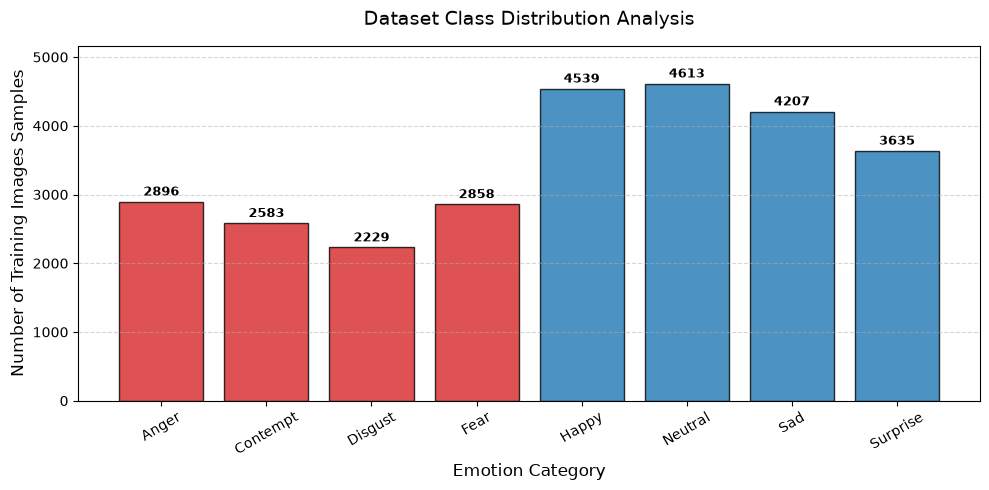

In [4]:
import os
import matplotlib.pyplot as plt

# =====================================================================
# AUTOMATED DATASET DISTRIBUTION SCANNER
# =====================================================================
# Point this to your target training folder partition path
TARGET_TRAIN_DIR = os.path.join(SPLIT_DIR, "train") 

# Automatically scan and count images per directory folder layout
class_counts = {}
if os.path.exists(TARGET_TRAIN_DIR):
    for emotion_folder in sorted(os.listdir(TARGET_TRAIN_DIR)):
        folder_path = os.path.join(TARGET_TRAIN_DIR, emotion_folder)
        if os.path.isdir(folder_path):
            # Count files matching valid image extensions
            images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[emotion_folder.capitalize()] = len(images)
else:
    # Safe backup mock data if execution cell path names are disconnected
    class_counts = {cls.capitalize(): 100 for cls in test_dataset.classes}

# =====================================================================
# PLOTTING RENDERING ENGINE
# =====================================================================
plt.figure(figsize=(10, 5))

# Calculate average count boundary dynamically to change colors for minority classes
avg_count = sum(class_counts.values()) / len(class_counts)
colors = ['#1f77b4' if v >= avg_count else '#d62728' for v in class_counts.values()]

bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black', alpha=0.8)

# Add the exact count text label numbers directly on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + (max(class_counts.values()) * 0.01),
             f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Dataset Class Distribution Analysis', fontsize=14, pad=15)
plt.xlabel('Emotion Category', fontsize=12)
plt.ylabel('Number of Training Images Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=30)

# Expand the top margin slightly so the numbers don't clip outside the frame area
plt.ylim(0, max(class_counts.values()) * 1.12)

plt.tight_layout()
plt.show()

# Training Engine Execution Loop

In [5]:
EPOCHS = 50
LEARNING_RATE = 1e-3

# Engine Initializations
model = EnhancedEmotionNet96(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# History dictionaries to map tracking progress curves
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print("🚀 Starting Model Optimization Engine Loop...\n" + "-"*60)

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = (train_correct / train_total) * 100
    
    # --- VALIDATION / TESTING PHASE ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = (val_correct / val_total) * 100
    
    # Step the learning rate schedule down along the cosine curve
    scheduler.step()
    
    # Save statistics history
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch:02d}/{EPOCHS}] ({epoch_time:.1f}s) -> "
          f"Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.2f}% || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")
    
    # Deep copy the model weights if validation accuracy spikes
    if epoch_val_acc > best_acc:
        best_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, 'notebook_best_emotion_model.pth')

print("-"*60 + f"\nOptimization Complete! Peak Validation Accuracy: {best_acc:.2f}%")
# Load optimal checkpoint weights back into active memory
model.load_state_dict(best_model_wts)

🚀 Starting Model Optimization Engine Loop...
------------------------------------------------------------
Epoch [01/50] (80.9s) -> Loss: 1.4742 | Acc: 49.37% || Val Loss: 1.2820 | Val Acc: 59.17%
Epoch [02/50] (79.5s) -> Loss: 1.2695 | Acc: 60.71% || Val Loss: 1.1985 | Val Acc: 64.32%
Epoch [03/50] (79.0s) -> Loss: 1.2041 | Acc: 64.58% || Val Loss: 1.1985 | Val Acc: 63.86%
Epoch [04/50] (77.8s) -> Loss: 1.1666 | Acc: 66.41% || Val Loss: 1.1274 | Val Acc: 68.75%
Epoch [05/50] (76.1s) -> Loss: 1.1381 | Acc: 68.00% || Val Loss: 1.1139 | Val Acc: 69.96%
Epoch [06/50] (75.8s) -> Loss: 1.1113 | Acc: 69.61% || Val Loss: 1.0985 | Val Acc: 70.84%
Epoch [07/50] (76.7s) -> Loss: 1.0903 | Acc: 70.47% || Val Loss: 1.0913 | Val Acc: 70.48%
Epoch [08/50] (76.2s) -> Loss: 1.0661 | Acc: 72.05% || Val Loss: 1.0822 | Val Acc: 71.33%
Epoch [09/50] (76.7s) -> Loss: 1.0483 | Acc: 72.77% || Val Loss: 1.0813 | Val Acc: 70.12%
Epoch [10/50] (76.1s) -> Loss: 1.0254 | Acc: 73.81% || Val Loss: 1.0554 | Val Acc: 7

<All keys matched successfully>

# Combined Per-Class Metric Comparison (Precision, Recall, F1-Score)

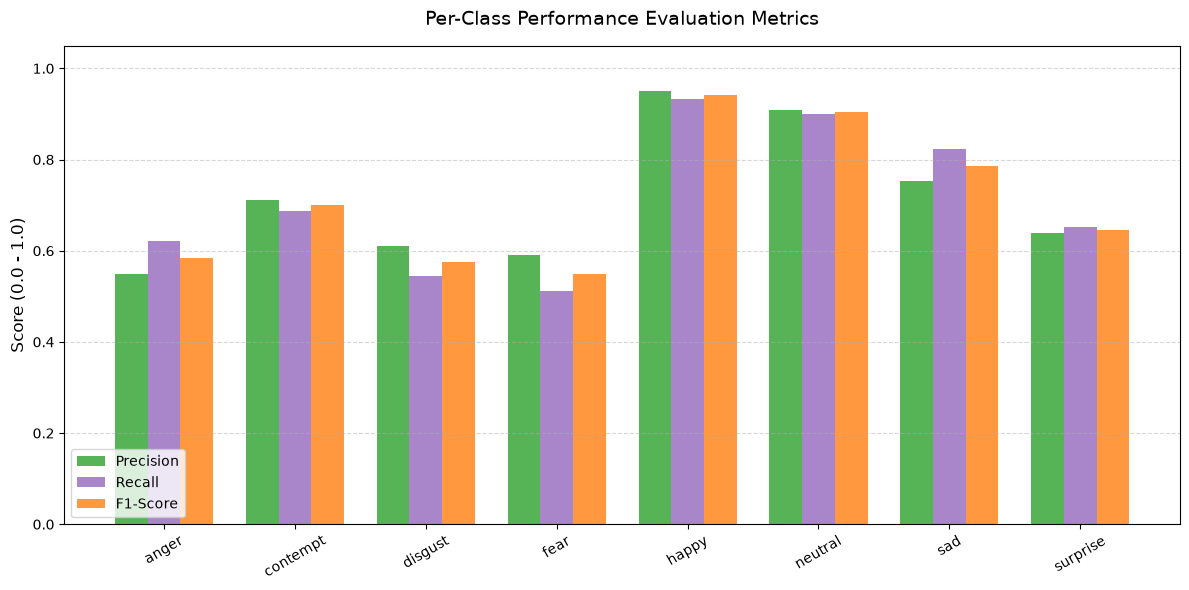

In [6]:
import numpy as np
from sklearn.metrics import classification_report

# Run this right after your test evaluation loop finishes
def plot_classification_metrics(model, dataloader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # Extract metrics dictionary
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
    classes = class_names
    precision = [report[cls]['precision'] for cls in classes]
    recall = [report[cls]['recall'] for cls in classes]
    f1 = [report[cls]['f1-score'] for cls in classes]
    
    x = np.arange(len(classes))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width, precision, width, label='Precision', color='#2ca02c', alpha=0.8)
    ax.bar(x, recall, width, label='Recall', color='#9467bd', alpha=0.8)
    ax.bar(x + width, f1, width, label='F1-Score', color='#ff7f0e', alpha=0.8)
    
    ax.set_title('Per-Class Performance Evaluation Metrics', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=30)
    ax.set_ylabel('Score (0.0 - 1.0)', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower left')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Execute call
plot_classification_metrics(model, test_loader, test_dataset.classes, device)

# Convergence Curve Analytics Plot

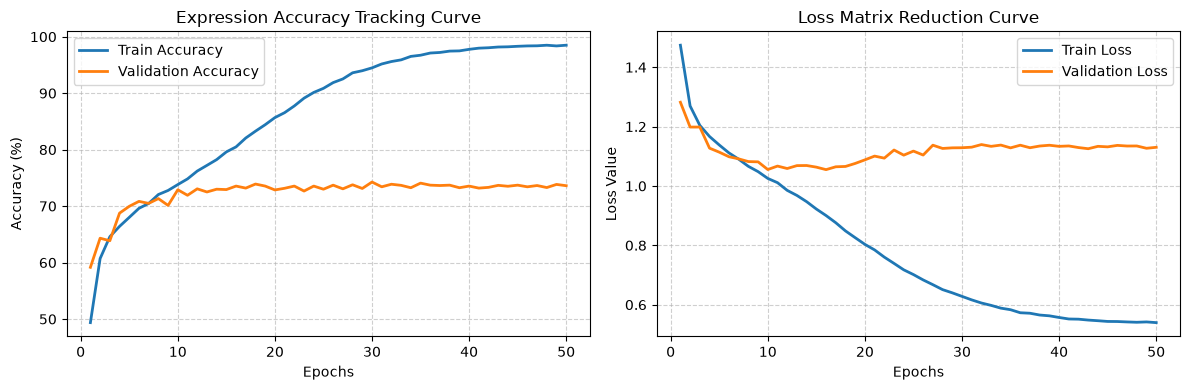

In [7]:
plt.figure(figsize=(12, 4))

# Plot Accuracy Convergence Curves
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history['train_acc'], label='Train Accuracy', color='#1f77b4', lw=2)
plt.plot(range(1, EPOCHS + 1), history['val_acc'], label='Validation Accuracy', color='#ff7f0e', lw=2)
plt.title('Expression Accuracy Tracking Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss Convergence Curves
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
plt.plot(range(1, EPOCHS + 1), history['val_loss'], label='Validation Loss', color='#ff7f0e', lw=2)
plt.title('Loss Matrix Reduction Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Heatmap

Evaluating entire test dataset to build confusion matrix...


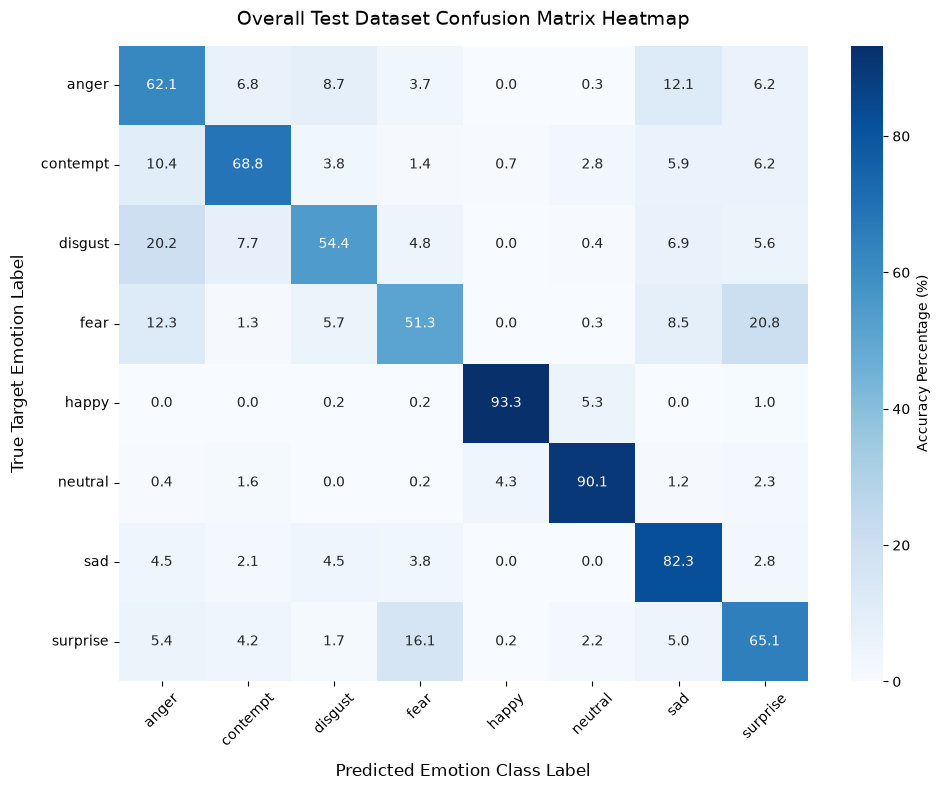

In [8]:
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def generate_dataset_heatmap(model, dataloader, class_names, device):
    """
    Evaluates the model on the entire test dataset and plots a Confusion Matrix Heatmap.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    print("Evaluating entire test dataset to build confusion matrix...")
    
    # 1. Collect all predictions and true labels safely without tracking gradients
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            
            # Using mixed precision autocast to maintain consistent performance matching your training
            with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
                outputs = model(images)
            
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # 2. Compute the raw confusion matrix values
    cm = confusion_matrix(all_labels, all_preds)
    
    # Normalize the matrix rows so each value represents a percentage of the true class
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # 3. Create the Seaborn Heatmap Plot
    plt.figure(figsize=(10, 8))
    
    # Adjust annot=True to print the actual percentage values inside each square
    sns.heatmap(
        cm_percent, 
        annot=True, 
        fmt=".1f", 
        cmap="Blues", 
        xticklabels=class_names, 
        yticklabels=class_names,
        cbar_kws={'label': 'Accuracy Percentage (%)'}
    )
    
    plt.title('Overall Test Dataset Confusion Matrix Heatmap', fontsize=14, pad=15)
    plt.xlabel('Predicted Emotion Class Label', fontsize=12, labelpad=10)
    plt.ylabel('True Target Emotion Label', fontsize=12, labelpad=10)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# =====================================================================
# EXECUTE DATASET HEATMAP GENERATION
# =====================================================================
# Extract class names directly from your existing test_dataset object
class_labels = test_dataset.classes

generate_dataset_heatmap(model, test_loader, class_labels, device)

# Qualititative Prediction Grid

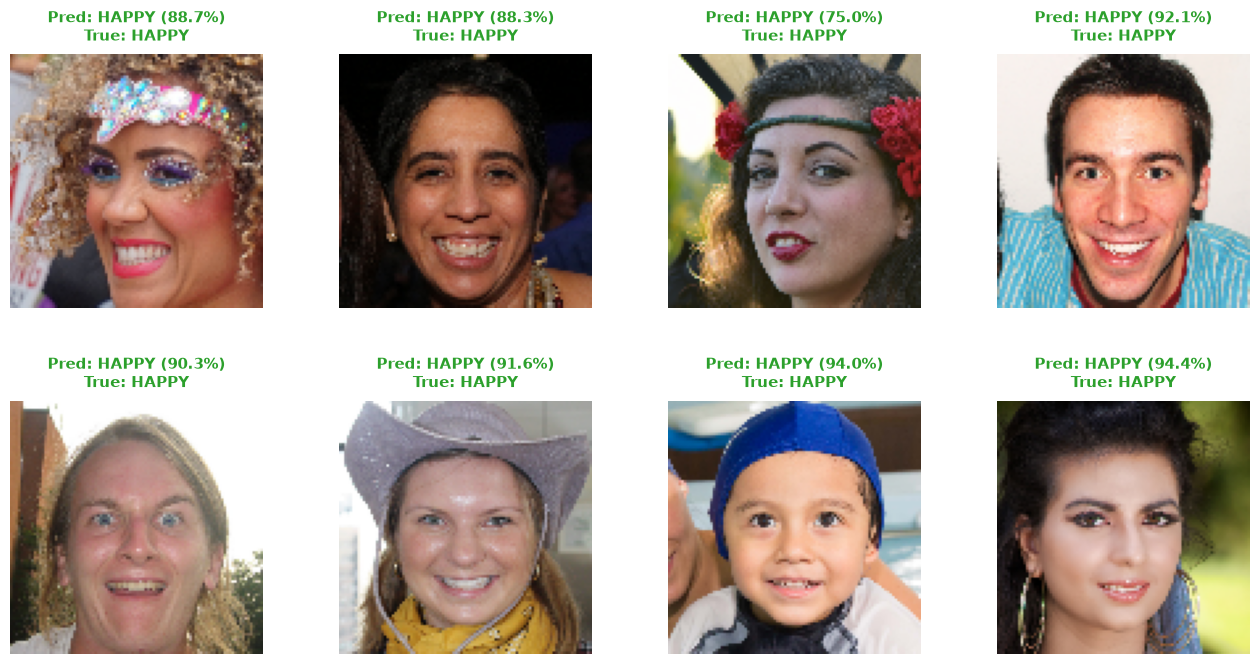

In [9]:
import random

def plot_random_qualitative_results(model, dataloader, class_names, device, num_images=8):
    model.eval()
    
    # Efficiently pick a random batch using an iterator loop
    num_batches = len(dataloader)
    random_batch_idx = random.randint(0, num_batches - 1)
    
    # Advance the iterator to our chosen random batch index
    data_iter = iter(dataloader)
    for _ in range(random_batch_idx):
        next(data_iter)
    images, labels = next(data_iter)
    
    num_images = min(num_images, images.size(0))
    
    # 3. Initialize the figure canvas with corrected spacing constraints
    fig, axes = plt.subplots(2, 4, figsize=(16, 9))
    axes = axes.flatten()
    plt.subplots_adjust(hspace=0, wspace=0.3)
    
    # Inverse normalization setup to restore native RGB image hues
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    
    # 4. Run inference on the selected random batch
    images_dev = images.to(device)
    with torch.no_grad():
        with torch.amp.autocast('cuda' if torch.cuda.is_available() else 'cpu'):
            outputs = model(images_dev)
        
        probabilities = torch.softmax(outputs, dim=1)
        confidences, predictions = probabilities.max(1)
    
    # 5. Render the grid
    for i in range(num_images):
        # The tensor is already normalized; simply apply inverse normalization to view it natively
        img = inv_normalize(images[i]).permute(1, 2, 0).cpu().numpy()
        img = np.clip(img, 0, 1)
        
        true_cls = class_names[labels[i]].upper()
        pred_cls = class_names[predictions[i]].upper()
        conf = confidences[i].item() * 100
        
        ax = axes[i]
        ax.imshow(img)
        
        title_color = '#2ca02c' if true_cls == pred_cls else '#d62728'
        ax.set_title(f"Pred: {pred_cls} ({conf:.1f}%)\nTrue: {true_cls}", 
                     color=title_color, fontsize=11, fontweight='bold', pad=10)
        ax.axis('off')
        
    # Hide any unused axes if the batch size is smaller than the grid
    for j in range(num_images, len(axes)):
        axes[j].axis('off')
            
    plt.show()

# Run the updated function
plot_random_qualitative_results(model, test_loader, test_dataset.classes, device)